## Alzheimer's MRI Dataset - Comprehensive Data Audit
 
### **Objective:** Perform thorough exploratory data analysis (EDA) on the Alzheimer's MRI dataset

#### Steps Covered:
 1. Dataset loading and structure verification
 2. Class distribution analysis
 3. Corrupted file detection
 4. Image dimension analysis
 5. Color channel analysis (grayscale vs RGB)
 6. Pixel statistics per class
 7. Sample visualization
 8. Comprehensive summary report

In [1]:
# 1. Import Required Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict
import pandas as pd
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create output directories
os.makedirs('reports/figures', exist_ok=True)
os.makedirs('reports/data', exist_ok=True)

In [5]:
#2- load the dataset
data_dir = Path('../../data/raw/train').resolve()
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

print("="*60)
print("DATASET LOADING")
print("="*60)

if not data_dir.exists():
    raise FileNotFoundError(f"Directory {data_dir} does not exist. Please check the path.")
else:
    print(f" Classes found: {class_names}")

# Verify each class folder exists
for class_name in class_names:
    class_path = data_dir / class_name
    if class_path.exists():
        print(f"  ✓ {class_name} folder exists")
    else:
        print(f"  ✗ WARNING: {class_name} folder not found!")


DATASET LOADING
 Classes found: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
  ✓ MildDemented folder exists
  ✓ ModerateDemented folder exists
  ✓ NonDemented folder exists
  ✓ VeryMildDemented folder exists


In [6]:
#count the number of images in each class

def count_images_per_class(dataset_path, class_names):
    """
    Count number of images in each class folder with validation.
    Returns dictionary of counts and total images.
    """
    class_counts = {}
    total_images = 0
    
    print("\n" + "="*60)
    print("CLASS DISTRIBUTION ANALYSIS")
    print("="*60)
    
    for class_name in class_names:
        class_path = dataset_path / class_name
        if class_path.exists():
            # Count image files (common extensions)
            images = [f for f in os.listdir(class_path) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif'))]
            class_counts[class_name] = len(images)
            total_images += len(images)
            print(f" {class_name:<20}: {len(images):>5} images")
        else:
            print(f" Warning: {class_name} folder not found")
            class_counts[class_name] = 0
    
    print("-"*60)
    print(f" TOTAL IMAGES: {total_images}")
    print("="*60)
    
    return class_counts, total_images

class_counts, total_images = count_images_per_class(data_dir, class_names)


CLASS DISTRIBUTION ANALYSIS
 MildDemented        :   896 images
 ModerateDemented    :    64 images
 NonDemented         :  3200 images
 VeryMildDemented    :  2240 images
------------------------------------------------------------
 TOTAL IMAGES: 6400


we can see an imbalance in pur dataset we need to fix

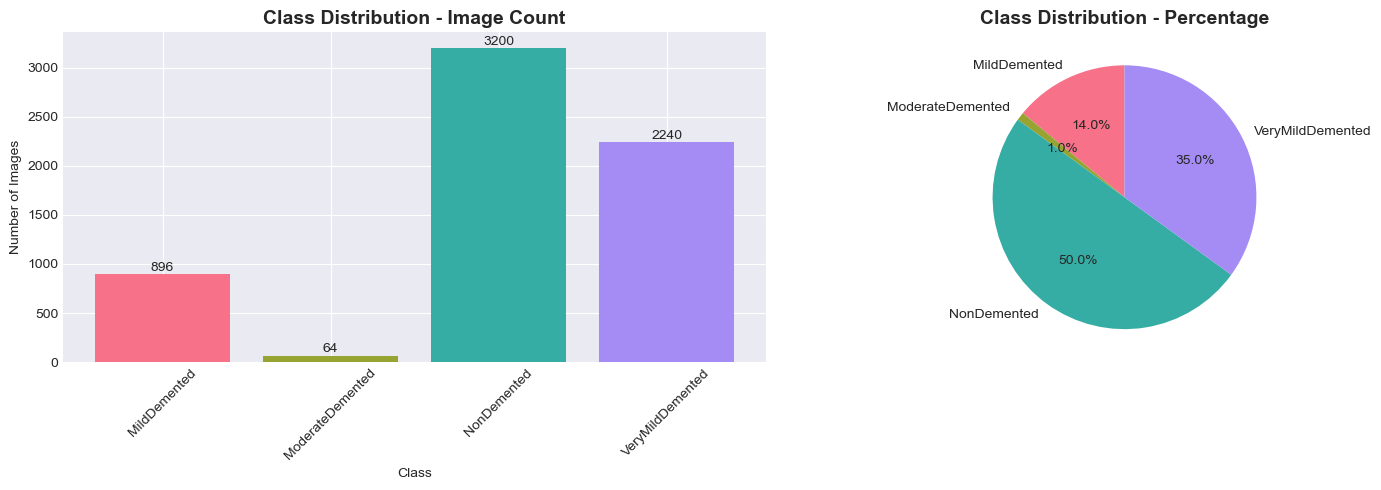

 Class distribution plot saved


In [7]:
# Plot class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
colors = sns.color_palette("husl", len(class_counts))

# Bar plot
bars = ax1.bar(class_counts.keys(), class_counts.values(), color=colors)
ax1.set_title('Class Distribution - Image Count', fontsize=14, fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Images')
ax1.tick_params(axis='x', rotation=45)

# Add counts on top of bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 5, str(height), 
             ha='center', va='bottom', fontsize=10)

# Pie chart
wedges, texts, autotexts = ax2.pie(class_counts.values(), 
                                     labels=class_counts.keys(), 
                                     autopct='%1.1f%%',
                                     colors=colors, 
                                     startangle=90)
ax2.set_title('Class Distribution - Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/figures/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Class distribution plot saved")

**Observation:** There's significant class imbalance:
 - NonDemented (50.0%) and VeryMildDemented (35.0%) dominate
 - ModerateDemented (1.0%) is severely underrepresented
 - This imbalance will need to be addressed during model training

In [8]:
#5 - check for corrupted images
def check_corrupted_images(dataset_path, class_names):
    """
    Thoroughly check for corrupted images in the dataset.
    Returns list of corrupted images and their errors.
    """
    corrupted_images = []
    total_checked = 0
    
    print("\n" + "="*60)
    print("CORRUPTED IMAGE DETECTION")
    print("="*60)
    
    for class_name in class_names:
        class_path = dataset_path / class_name
        if not class_path.exists():
            continue
            
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif'))]
        
        print(f"\n Checking {class_name} ({len(images)} images)...")
        
        for img_name in images:
            img_path = class_path / img_name
            total_checked += 1
            
            try:
                # Method 1: Try to open with PIL
                with Image.open(img_path) as img:
                    img.verify()  # Verify integrity
                
                # Method 2: Try to open with OpenCV
                img_cv = cv2.imread(str(img_path))
                if img_cv is None:
                    raise ValueError("OpenCV failed to read image")
                    
            except (IOError, SyntaxError, ValueError) as e:
                corrupted_images.append({
                    'class': class_name,
                    'file': img_name,
                    'path': str(img_path),
                    'error': str(e)
                })
                print(f"  Corrupted: {img_name} - {str(e)[:50]}...")
        
        print(f"  ✓ {len(images) - sum(1 for x in corrupted_images if x['class'] == class_name)} good images")
    
    print("-"*60)
    print(f" TOTAL IMAGES CHECKED: {total_checked}")
    print(f" CORRUPTED IMAGES FOUND: {len(corrupted_images)}")
    print("="*60)
    
    return corrupted_images

corrupted = check_corrupted_images(data_dir, class_names)

# Save corrupted list if any found
if corrupted:
    df_corrupted = pd.DataFrame(corrupted)
    df_corrupted.to_csv('reports/data/corrupted_images.csv', index=False)
    print(" Corrupted images list saved to reports/data/corrupted_images.csv")


CORRUPTED IMAGE DETECTION

 Checking MildDemented (896 images)...
  ✓ 896 good images

 Checking ModerateDemented (64 images)...
  ✓ 64 good images

 Checking NonDemented (3200 images)...
  ✓ 3200 good images

 Checking VeryMildDemented (2240 images)...
  ✓ 2240 good images
------------------------------------------------------------
 TOTAL IMAGES CHECKED: 6400
 CORRUPTED IMAGES FOUND: 0


In [9]:
#6- Image Dimension Analysis
def analyze_image_dimensions(dataset_path, class_names, sample_size=None):
    """
    Analyze image dimensions and aspect ratios.
    If sample_size is None, analyze all images (default for small datasets).
    """
    dimensions = defaultdict(lambda: {'heights': [], 'widths': [], 'aspect_ratios': []})
    
    print("\n" + "="*60)
    print("IMAGE DIMENSION ANALYSIS")
    print("="*60)
    
    for class_name in class_names:
        class_path = dataset_path / class_name
        if not class_path.exists():
            continue
            
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif'))]
        
        # Determine sample size
        if sample_size is None:
            sample_images = images  # Analyze all images
        else:
            sample_images = np.random.choice(images, min(sample_size, len(images)), replace=False)
        
        for img_name in sample_images:
            img_path = class_path / img_name
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                    dimensions[class_name]['widths'].append(width)
                    dimensions[class_name]['heights'].append(height)
                    dimensions[class_name]['aspect_ratios'].append(width / height)
            except Exception as e:
                print(f" Error processing {img_name}: {e}")
    
    # Print summary statistics
    for class_name in class_names:
        if dimensions[class_name]['widths']:
            widths = dimensions[class_name]['widths']
            heights = dimensions[class_name]['heights']
            ratios = dimensions[class_name]['aspect_ratios']
            
            print(f"\n {class_name}:")
            print(f"  Sample size: {len(widths)} images")
            print(f"  Width:  min={min(widths):4d}px, max={max(widths):4d}px, mean={np.mean(widths):.1f}px")
            print(f"  Height: min={min(heights):4d}px, max={max(heights):4d}px, mean={np.mean(heights):.1f}px")
            print(f"  Aspect ratio: min={min(ratios):.3f}, max={max(ratios):.3f}, mean={np.mean(ratios):.3f}")
            print(f"  Unique sizes: {len(set(zip(widths, heights)))} different dimensions")
    
    return dimensions

# Analyze all images (dataset is manageable size)
dimensions = analyze_image_dimensions(data_dir, class_names, sample_size=None)



IMAGE DIMENSION ANALYSIS

 MildDemented:
  Sample size: 896 images
  Width:  min= 128px, max= 128px, mean=128.0px
  Height: min= 128px, max= 128px, mean=128.0px
  Aspect ratio: min=1.000, max=1.000, mean=1.000
  Unique sizes: 1 different dimensions

 ModerateDemented:
  Sample size: 64 images
  Width:  min= 128px, max= 128px, mean=128.0px
  Height: min= 128px, max= 128px, mean=128.0px
  Aspect ratio: min=1.000, max=1.000, mean=1.000
  Unique sizes: 1 different dimensions

 NonDemented:
  Sample size: 3200 images
  Width:  min= 128px, max= 128px, mean=128.0px
  Height: min= 128px, max= 128px, mean=128.0px
  Aspect ratio: min=1.000, max=1.000, mean=1.000
  Unique sizes: 1 different dimensions

 VeryMildDemented:
  Sample size: 2240 images
  Width:  min= 128px, max= 128px, mean=128.0px
  Height: min= 128px, max= 128px, mean=128.0px
  Aspect ratio: min=1.000, max=1.000, mean=1.000
  Unique sizes: 1 different dimensions


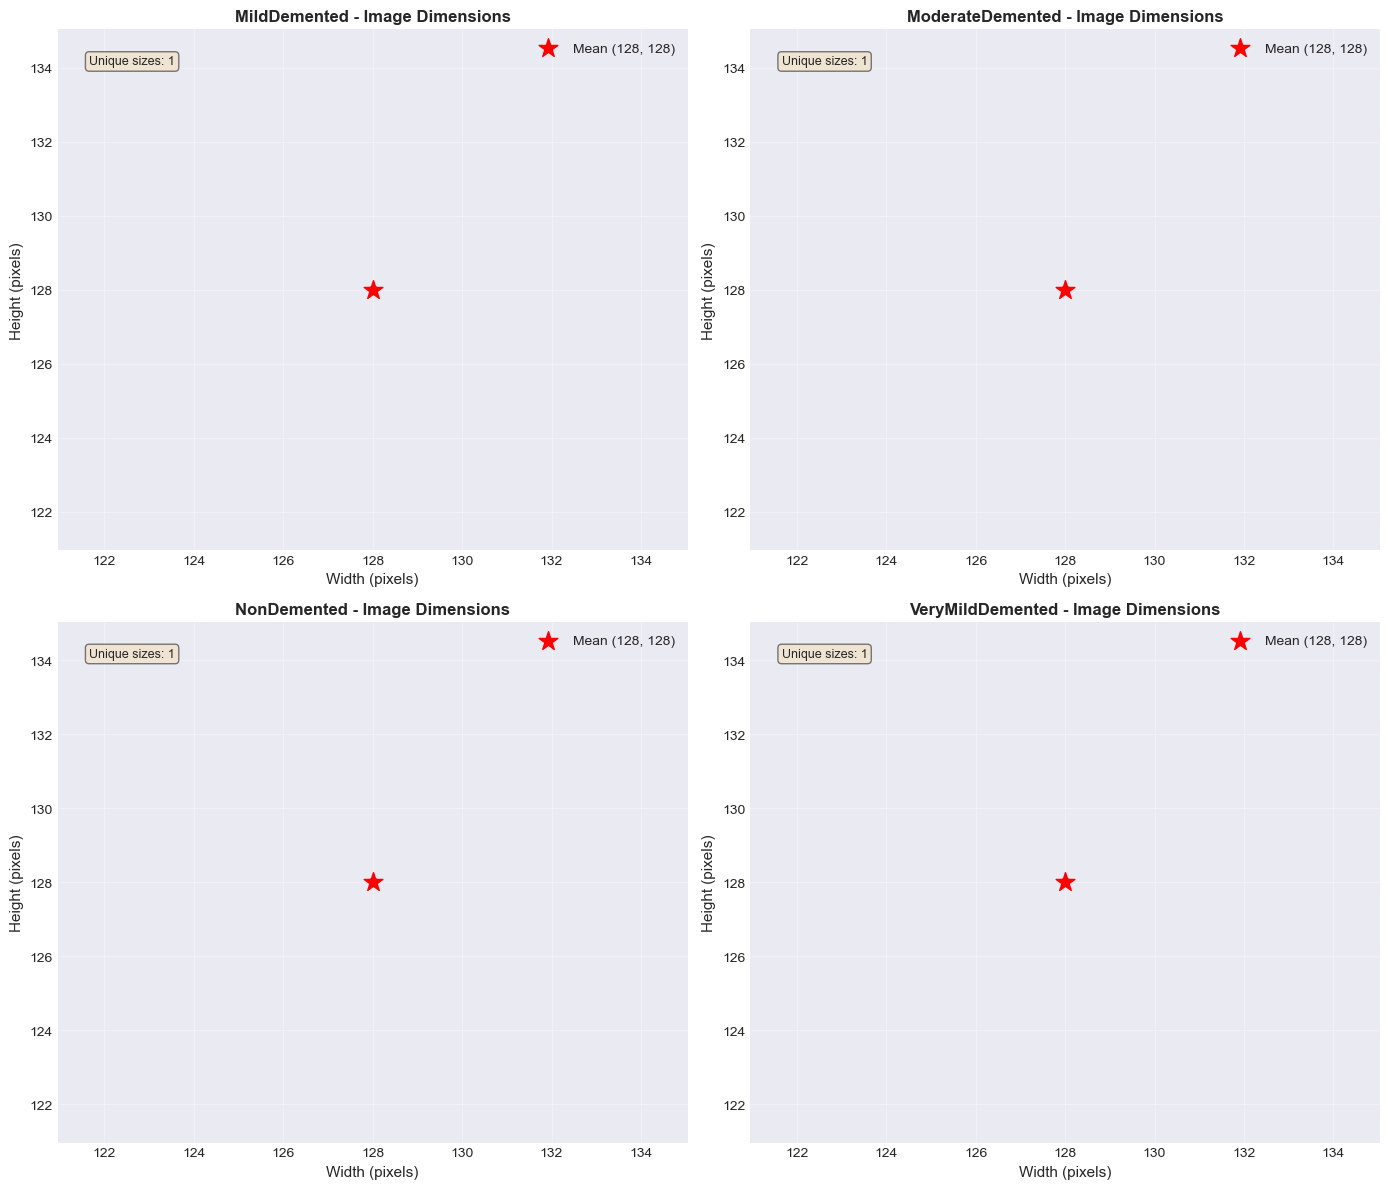

In [10]:
# Dimension Visualization
# Plot dimensions scatter
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, class_name in enumerate(class_names):
    if idx < 4 and dimensions[class_name]['heights']:
        ax = axes[idx]
        widths = dimensions[class_name]['widths']
        heights = dimensions[class_name]['heights']
        
        # Scatter plot
        ax.scatter(widths, heights, alpha=0.6, s=30)
        ax.set_xlabel('Width (pixels)', fontsize=11)
        ax.set_ylabel('Height (pixels)', fontsize=11)
        ax.set_title(f'{class_name} - Image Dimensions', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add mean point
        mean_w = np.mean(widths)
        mean_h = np.mean(heights)
        ax.scatter(mean_w, mean_h, color='red', s=200, marker='*', 
                  label=f'Mean ({mean_w:.0f}, {mean_h:.0f})', zorder=5)
        ax.legend()
        
        # Add stats box
        stats_text = f'Unique sizes: {len(set(zip(widths, heights)))}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('reports/figures/image_dimensions_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
#check if images are RGB or Grayscale
import os
import cv2
import numpy as np

def analyze_color_channels(dataset_path, class_names, sample_size=50):
    """
    Comprehensive color channel analysis.
    Distinguishes between true grayscale and RGB images.
    """
    color_info = defaultdict(lambda: {
        'true_grayscale': 0,
        'grayscale_as_rgb': 0,
        'real_rgb': 0,
        'rgba': 0,
        'samples': []
    })
    
    print("\n" + "="*60)
    print("COLOR CHANNEL ANALYSIS")
    print("="*60)
    
    for class_name in class_names:
        class_path = dataset_path / class_name
        if not class_path.exists():
            continue
            
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        sample_images = np.random.choice(
            images,
            min(sample_size, len(images)),
            replace=False
        )
        
        for img_file in sample_images:
            img_path = class_path / img_file
            
            # Load with OpenCV
            img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
            
            if img is None:
                continue
            
            # Analyze channels
            if len(img.shape) == 2:
                # True grayscale (single channel)
                color_info[class_name]['true_grayscale'] += 1
                color_info[class_name]['samples'].append(('grayscale', img_file))
                
            elif len(img.shape) == 3:
                if img.shape[2] == 4:
                    # RGBA
                    color_info[class_name]['rgba'] += 1
                    color_info[class_name]['samples'].append(('rgba', img_file))
                    
                elif img.shape[2] == 3:
                    # Check if all channels are identical (grayscale stored as RGB)
                    if np.array_equal(img[:,:,0], img[:,:,1]) and \
                       np.array_equal(img[:,:,1], img[:,:,2]):
                        color_info[class_name]['grayscale_as_rgb'] += 1
                        color_info[class_name]['samples'].append(('grayscale_rgb', img_file))
                    else:
                        color_info[class_name]['real_rgb'] += 1
                        color_info[class_name]['samples'].append(('rgb', img_file))
    
    # Print summary
    for class_name in class_names:
        counts = color_info[class_name]
        total = sum([counts['true_grayscale'], counts['grayscale_as_rgb'], 
                     counts['real_rgb'], counts['rgba']])
        
        if total > 0:
            print(f"\n {class_name} (total samples: {total}):")
            
            if counts['true_grayscale']:
                pct = counts['true_grayscale']/total*100
                print(f"  • True Grayscale: {counts['true_grayscale']:3d} images ({pct:.1f}%)")
            
            if counts['grayscale_as_rgb']:
                pct = counts['grayscale_as_rgb']/total*100
                print(f"  • Grayscale as RGB: {counts['grayscale_as_rgb']:3d} images ({pct:.1f}%)")
            
            if counts['real_rgb']:
                pct = counts['real_rgb']/total*100
                print(f"  • Real RGB: {counts['real_rgb']:3d} images ({pct:.1f}%)")
            
            if counts['rgba']:
                pct = counts['rgba']/total*100
                print(f"  • RGBA: {counts['rgba']:3d} images ({pct:.1f}%)")
    
    return color_info

color_analysis = analyze_color_channels(data_dir, class_names, sample_size=50)



COLOR CHANNEL ANALYSIS

 MildDemented (total samples: 50):
  • True Grayscale:  50 images (100.0%)

 ModerateDemented (total samples: 50):
  • True Grayscale:  50 images (100.0%)

 NonDemented (total samples: 50):
  • True Grayscale:  50 images (100.0%)

 VeryMildDemented (total samples: 50):
  • True Grayscale:  50 images (100.0%)


In [12]:
# Compute pixel stats per class 
def compute_pixel_stats(dataset_path, class_names, sample_size=50):
    """
    Compute comprehensive pixel statistics per class.
    """
    pixel_stats = defaultdict(dict)
    
    print("\n" + "="*60)
    print("PIXEL STATISTICS ANALYSIS")
    print("="*60)
    
    for class_name in class_names:
        class_path = dataset_path / class_name
        if not class_path.exists():
            continue
            
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        sample_images = np.random.choice(images, min(sample_size, len(images)), replace=False)
        pixel_values = []
        
        for img_file in sample_images:
            img_path = class_path / img_file
            img = cv2.imread(str(img_path))
            if img is not None:
                pixel_values.append(img.flatten())
        
        if pixel_values:
            all_pixels = np.concatenate(pixel_values)
            
            pixel_stats[class_name] = {
                'mean': np.mean(all_pixels),
                'std': np.std(all_pixels),
                'min': np.min(all_pixels),
                'max': np.max(all_pixels),
                'median': np.median(all_pixels),
                'p25': np.percentile(all_pixels, 25),
                'p75': np.percentile(all_pixels, 75)
            }
            
            print(f"\n {class_name}:")
            print(f"  Mean:     {pixel_stats[class_name]['mean']:.2f}")
            print(f"  Std:      {pixel_stats[class_name]['std']:.2f}")
            print(f"  Median:   {pixel_stats[class_name]['median']:.2f}")
            print(f"  Range:    [{pixel_stats[class_name]['min']}, {pixel_stats[class_name]['max']}]")
            print(f"  IQR:      [{pixel_stats[class_name]['p25']:.2f}, {pixel_stats[class_name]['p75']:.2f}]")
    
    return pixel_stats

pixel_stats = compute_pixel_stats(data_dir, class_names, sample_size=50)


PIXEL STATISTICS ANALYSIS

 MildDemented:
  Mean:     66.18
  Std:      80.09
  Median:   10.00
  Range:    [0, 255]
  IQR:      [0.00, 138.00]

 ModerateDemented:
  Mean:     68.90
  Std:      82.64
  Median:   18.00
  Range:    [0, 255]
  IQR:      [0.00, 144.00]

 NonDemented:
  Mean:     71.14
  Std:      82.49
  Median:   23.00
  Range:    [0, 255]
  IQR:      [0.00, 146.00]

 VeryMildDemented:
  Mean:     69.61
  Std:      82.04
  Median:   21.00
  Range:    [0, 255]
  IQR:      [0.00, 144.00]


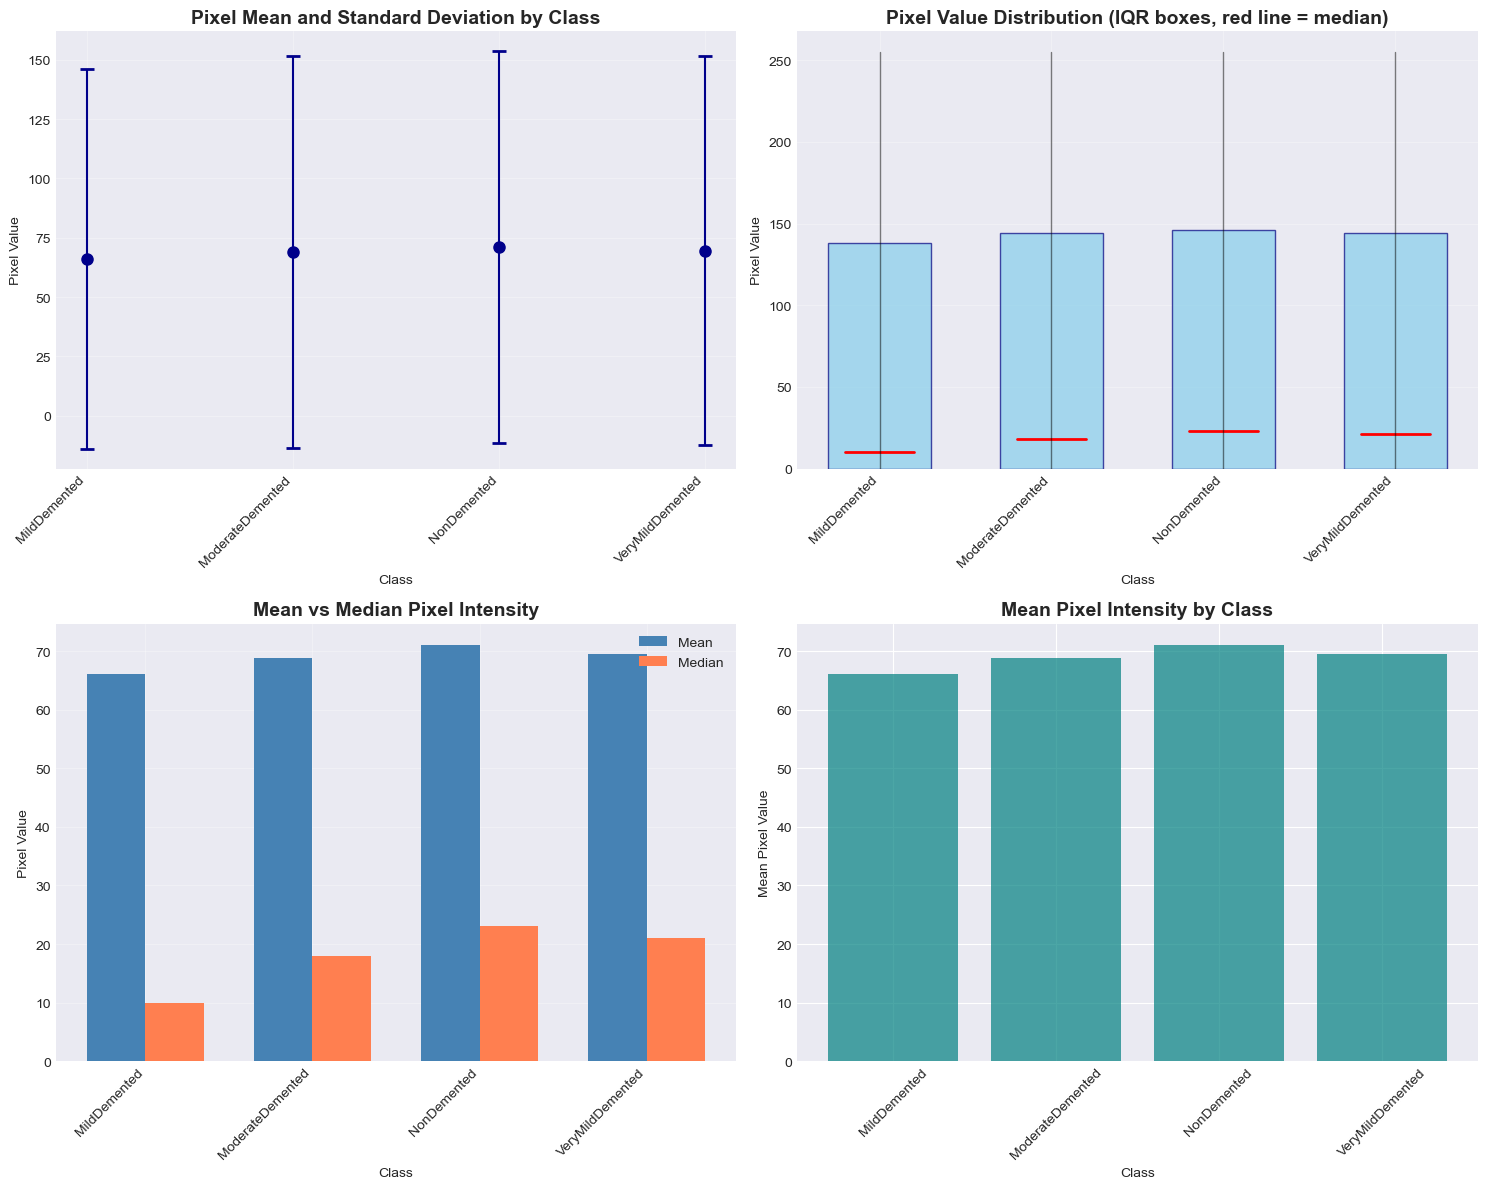

In [13]:
# Plot pixel value distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Mean and Std with error bars
ax1 = axes[0, 0]
classes = list(pixel_stats.keys())
means = [pixel_stats[c]['mean'] for c in classes if c in pixel_stats]
stds = [pixel_stats[c]['std'] for c in classes if c in pixel_stats]
valid_classes = [c for c in classes if c in pixel_stats]

ax1.errorbar(range(len(valid_classes)), means, yerr=stds, fmt='o', 
             capsize=5, capthick=2, markersize=8, color='darkblue')
ax1.set_xticks(range(len(valid_classes)))
ax1.set_xticklabels(valid_classes, rotation=45, ha='right')
ax1.set_xlabel('Class')
ax1.set_ylabel('Pixel Value')
ax1.set_title('Pixel Mean and Standard Deviation by Class', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot 2: Box plot simulation with IQR
ax2 = axes[0, 1]
x_pos = np.arange(len(valid_classes))
means_list = [pixel_stats[c]['mean'] for c in valid_classes]
medians_list = [pixel_stats[c]['median'] for c in valid_classes]
q1_list = [pixel_stats[c]['p25'] for c in valid_classes]
q3_list = [pixel_stats[c]['p75'] for c in valid_classes]
mins_list = [pixel_stats[c]['min'] for c in valid_classes]
maxs_list = [pixel_stats[c]['max'] for c in valid_classes]

# Draw boxes
for i, (q1, med, q3, mn, mx) in enumerate(zip(q1_list, medians_list, q3_list, mins_list, maxs_list)):
    ax2.bar(i, q3 - q1, bottom=q1, width=0.6, color='skyblue', alpha=0.7, edgecolor='navy')
    ax2.plot([i-0.2, i+0.2], [med, med], 'r-', linewidth=2)
    ax2.plot([i, i], [mn, mx], 'k-', linewidth=1, alpha=0.5)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(valid_classes, rotation=45, ha='right')
ax2.set_xlabel('Class')
ax2.set_ylabel('Pixel Value')
ax2.set_title('Pixel Value Distribution (IQR boxes, red line = median)', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Comparison bar chart
ax3 = axes[1, 0]
width = 0.35
x = np.arange(len(valid_classes))
ax3.bar(x - width/2, means_list, width, label='Mean', color='steelblue')
ax3.bar(x + width/2, medians_list, width, label='Median', color='coral')
ax3.set_xticks(x)
ax3.set_xticklabels(valid_classes, rotation=45, ha='right')
ax3.set_xlabel('Class')
ax3.set_ylabel('Pixel Value')
ax3.set_title('Mean vs Median Pixel Intensity', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Histogram of mean values
ax4 = axes[1, 1]
ax4.bar(valid_classes, means_list, color='teal', alpha=0.7)
ax4.set_xlabel('Class')
ax4.set_ylabel('Mean Pixel Value')
ax4.set_title('Mean Pixel Intensity by Class', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('reports/figures/pixel_statistics_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

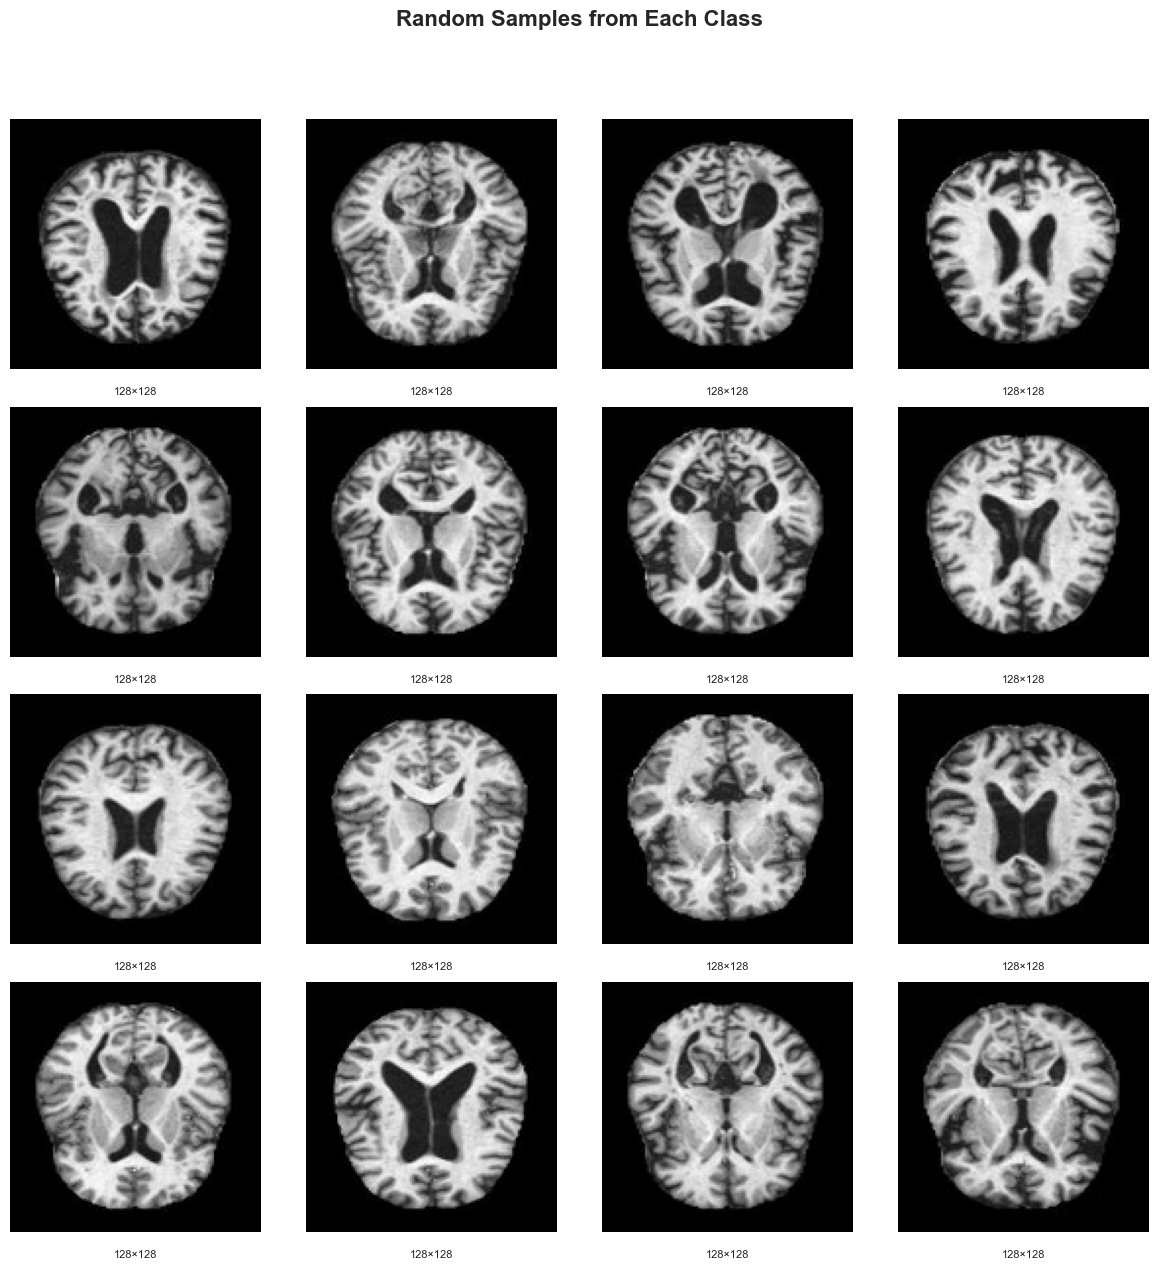

In [14]:
# Display random samples from each class
def display_random_samples(dataset_path, class_names, samples_per_class=4, seed=42):
    """
    Display random samples from each class with enhanced visualization.
    """
    np.random.seed(seed)
    
    fig, axes = plt.subplots(len(class_names), samples_per_class, 
                             figsize=(samples_per_class*3, len(class_names)*3))
    
    if len(class_names) == 1:
        axes = axes.reshape(1, -1)
    
    for row, class_name in enumerate(class_names):
        class_path = dataset_path / class_name
        if not class_path.exists():
            for col in range(samples_per_class):
                axes[row, col].axis('off')
                if col == 0:
                    axes[row, col].set_ylabel(class_name, fontsize=12, fontweight='bold')
            continue
            
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if not images:
            for col in range(samples_per_class):
                axes[row, col].axis('off')
                if col == 0:
                    axes[row, col].set_ylabel(class_name, fontsize=12, fontweight='bold')
            continue
            
        # Randomly select samples
        selected = np.random.choice(images, min(samples_per_class, len(images)), replace=False)
        
        for col, img_file in enumerate(selected):
            img_path = class_path / img_file
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            
            # Add size info
            h, w = img.shape[:2]
            axes[row, col].text(0.5, -0.1, f'{w}×{h}', 
                               transform=axes[row, col].transAxes,
                               fontsize=8, ha='center')
            
            if col == 0:
                axes[row, col].set_ylabel(f'{class_name}\n({len(images)} images)', 
                                         fontsize=10, fontweight='bold')
        
        # Fill empty slots
        for col in range(len(selected), samples_per_class):
            axes[row, col].axis('off')
    
    plt.suptitle('Random Samples from Each Class', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('reports/figures/sample_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

display_random_samples(data_dir, class_names, samples_per_class=4)

In [18]:
def generate_audit_report(class_counts, total_images, corrupted, dimensions, color_analysis, pixel_stats, class_names):
    """
    Generate comprehensive audit report.
    """
    report = f"""# Alzheimer's MRI Dataset - Comprehensive Audit Report

## 1. Dataset Overview
- **Total Images:** {total_images}
- **Number of Classes:** {len(class_names)}
- **Classes:** {', '.join(class_names)}

## 2. Class Distribution
"""
    for class_name, count in class_counts.items():
        percentage = (count / total_images * 100) if total_images > 0 else 0
        report += f"- **{class_name}:** {count} images ({percentage:.1f}%)\n"

    report += f"""
## 3. Data Quality
- **Corrupted Files Found:** {len(corrupted)}
"""
    if corrupted:
        report += "\n**Corrupted Files:**\n"
        for c in corrupted[:5]:  # Show first 5
            report += f"  - {c['class']}/{c['file']}: {c['error']}\n"
        if len(corrupted) > 5:
            report += f"  - ... and {len(corrupted) - 5} more\n"
    else:
        report += "\n- No corrupted files found - dataset is clean!\n"

    report += f"""
## 4. Image Properties
### Dimensions
"""
    for class_name in class_names:
        if class_name in dimensions and dimensions[class_name]['widths']:
            widths = dimensions[class_name]['widths']
            heights = dimensions[class_name]['heights']
            report += f"\n**{class_name}:**\n"
            report += f"- Dimensions: {len(set(zip(widths, heights)))} unique sizes\n"
            report += f"- Width range: {min(widths)}-{max(widths)}px\n"
            report += f"- Height range: {min(heights)}-{max(heights)}px\n"
        else:
            report += f"\n**{class_name}:** No dimension data available\n"

    report += f"""
### Color Channels
"""
    for class_name in class_names:
        if class_name in color_analysis:
            counts = color_analysis[class_name]
            # Calculate total excluding the 'samples' key
            total = (counts.get('true_grayscale', 0) + 
                    counts.get('grayscale_as_rgb', 0) + 
                    counts.get('real_rgb', 0) + 
                    counts.get('rgba', 0))
            
            if total > 0:
                report += f"\n**{class_name}:**\n"
                if counts.get('true_grayscale', 0):
                    pct = counts['true_grayscale']/total*100
                    report += f"- True Grayscale: {counts['true_grayscale']}/{total} ({pct:.1f}%)\n"
                if counts.get('grayscale_as_rgb', 0):
                    pct = counts['grayscale_as_rgb']/total*100
                    report += f"- Grayscale as RGB: {counts['grayscale_as_rgb']}/{total} ({pct:.1f}%)\n"
                if counts.get('real_rgb', 0):
                    pct = counts['real_rgb']/total*100
                    report += f"- Real RGB: {counts['real_rgb']}/{total} ({pct:.1f}%)\n"
                if counts.get('rgba', 0):
                    pct = counts['rgba']/total*100
                    report += f"- RGBA: {counts['rgba']}/{total} ({pct:.1f}%)\n"
        else:
            report += f"\n**{class_name}:** No color channel data available\n"

    report += f"""
### Pixel Statistics
"""
    for class_name in class_names:
        if class_name in pixel_stats and pixel_stats[class_name]:
            stats = pixel_stats[class_name]
            report += f"\n**{class_name}:**\n"
            report += f"- Mean: {stats['mean']:.2f} ± {stats['std']:.2f}\n"
            report += f"- Median: {stats['median']:.2f}\n"
            report += f"- Range: [{stats['min']}, {stats['max']}]\n"
        else:
            report += f"\n**{class_name}:** No pixel statistics available\n"

    report += f"""
## 5. Recommendations
Based on the audit findings:

1. **Class Imbalance Handling**
   - Severe imbalance detected (ModerateDemented has only {class_counts.get('ModerateDemented', 0)} images)
   - Recommended strategies: weighted loss, oversampling, augmentation

2. **Image Preprocessing**
   - Resize to uniform dimensions (suggested: 128×128px)
   - Normalize pixel values to [0, 1] or [-1, 1]
   - Convert all images to consistent color format

3. **Data Quality**
"""
    if corrupted:
        report += f"   - Remove {len(corrupted)} corrupted files before training\n"
    else:
        report += f"   - No corrupted files found - dataset is clean!\n"

    report += f"""
4. **Augmentation Recommendations**
   - For minority classes (ModerateDemented): heavy augmentation
   - Consider: rotation (±10°), zoom, flip, brightness adjustment

## 6. Files Generated
- `reports/figures/class_distribution.png` - Class distribution plots
- `reports/figures/image_dimensions_detailed.png` - Dimension analysis
- `reports/figures/pixel_statistics_detailed.png` - Pixel statistics
- `reports/figures/sample_visualization.png` - Sample images
- `reports/audit_report.md` - This report
"""
    if corrupted:
        report += "- `reports/data/corrupted_images.csv` - List of corrupted files\n"

    return report

# Generate and save report
report = generate_audit_report(class_counts, total_images, corrupted, 
                               dimensions, color_analysis, pixel_stats, class_names)

# Generate and save report
report = generate_audit_report(class_counts, total_images, corrupted, 
                               dimensions, color_analysis, pixel_stats, class_names)

# ADD THIS CODE:
# Write report to file
with open('reports/audit_report.md', 'w') as f:
    f.write(report)

# Print confirmation
print("\n" + "="*60)
print("AUDIT REPORT GENERATED")
print("="*60)
print(f"\nReport saved to: reports/audit_report.md")
print("\nPreview:")
print("="*60)
print(report[:500] + "...\n(truncated for display)")
print("="*60)
print("\nFull report saved to file.")



AUDIT REPORT GENERATED

Report saved to: reports/audit_report.md

Preview:
# Alzheimer's MRI Dataset - Comprehensive Audit Report

## 1. Dataset Overview
- **Total Images:** 6400
- **Number of Classes:** 4
- **Classes:** MildDemented, ModerateDemented, NonDemented, VeryMildDemented

## 2. Class Distribution
- **MildDemented:** 896 images (14.0%)
- **ModerateDemented:** 64 images (1.0%)
- **NonDemented:** 3200 images (50.0%)
- **VeryMildDemented:** 2240 images (35.0%)

## 3. Data Quality
- **Corrupted Files Found:** 0

- No corrupted files found - dataset is clean!

## ...
(truncated for display)

Full report saved to file.
